<a href="https://colab.research.google.com/github/cailyx/polyadenylation/blob/main/polyadenylation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

an initial toy model for looking at the energy of a loop of n number of A's, imposing 1) the energy of forcing a polymer with a particular end-to-end distance to circularize, and 2) the bending rigidity (dependent on the persistence length we increase as pabp packs on)

for 1) we assume a semiflexible fiber model (begin with an infinitely rigid rod and add in fluctuations) (MacKintosh)

note some assumptions are incomplete/inconsistent.

v_pabp = 39.69367424871327
r_pabp = 2.1161391921552135
250
18.997715101568716


/tmp/ipykernel_12407/3311025015.py:64: RuntimeWarning: divide by zero encountered in log
  G_loop_coated = -kbT * np.log(p_loop_coated)


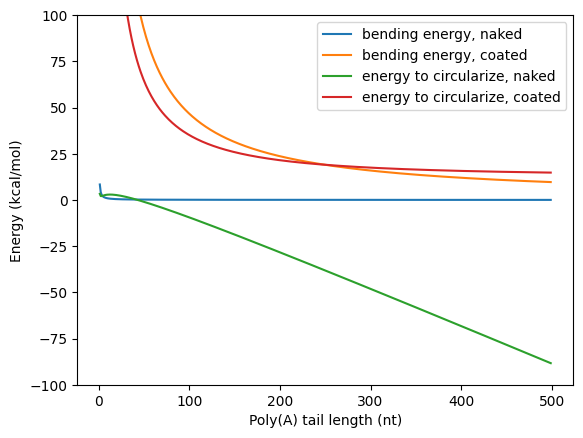

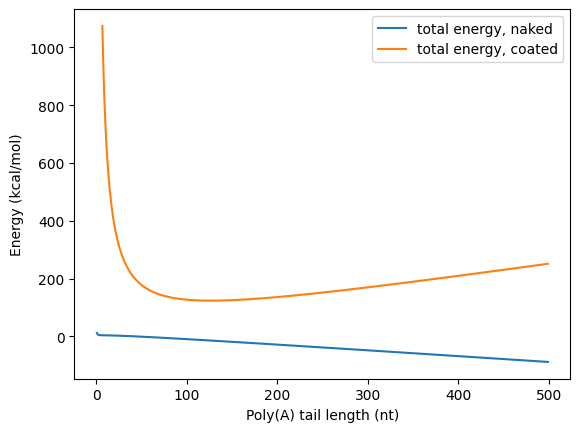

In [34]:
####v1
##goal- energy cost of adding PABPs into a circle, only considering bending energy and entropy costs of circularization.

import numpy as np
import matplotlib.pyplot as plt

#constants
v_pabp = (0.73e21/6.023e23) * 32750 #nm^3. pabpn1 is ~32.75 kDa.
r_pabp = (3*v_pabp/4/np.pi)**(1/3) #nm
print(f"v_pabp = {v_pabp}")  ####cross-check.
print(f"r_pabp = {r_pabp}")
d_nt = 2.6 + 0.34/2 #nm. nt is ~2.6 nm, distance bw adjacent nt ~0.34 nm.
num_A = np.arange(1, 500, 1)
nt_per_pabp = 11 #pabp(n1) footprint

# v_max_globule = 4/3*np.pi*(10)**3 #r = 10 nm. dont need this for now.

l_p_naked = 2 #persistence length in nm for ssRNA
stiff_pabp = 1000 #some stiffness factor when pabp binds (increasing l_p)
l_p_coated = l_p_naked + stiff_pabp

E_binding_all = [] #to collect gains from pabp binding.
E_bend_naked_all = [] #to consider first bending E of naked polya
E_bend_coated_all = [] #bending E of polya coated in pabp.
G_loop_naked_all = []  #energy of circularizing a naked polya... not too bad
G_loop_coated_all = [] #energy of circularizing a pabp-coated polya...


###################################
for n in num_A:
  length_polya = n*d_nt #this is simply the circumference 2pi*r, so
  r = length_polya/2/np.pi

  ##enthalpic gains of PABP binding.
  energy_per_pabp = -5
  num_pabp = n/nt_per_pabp
  E_binding = energy_per_pabp*num_pabp
  E_binding_all.append(E_binding)

  ##bending energy will drop since r is increasing..
  bend_stiff_n = l_p_naked*4.1 #(k_B)*T = 4.1 pN nm at RT, the bending rigidity.
  E_bend_naked = ((np.pi*bend_stiff_n)/r)*0.143 #we approx. as pi*kappa/r.
      ####see histone-wrapped DNA example!
      #the *0.143 is to convert pN*nm to kcal/mol.
  E_bend_naked_all.append(E_bend_naked)

  bend_stiff_c = l_p_coated*4.1 + (100*np.log(n+1)) #factor in slight PABP cooperativity that "worsens" the stiffen even more.
        #####kind of arbitrary. improve.
  E_bend_coated = ((np.pi*bend_stiff_c)/r)*0.143
  E_bend_coated_all.append(E_bend_coated)

  ##at the same time, we incur an entropic cost of bringing the ends together of an increasingly long chain:
      ##probability that the 2 ends find each other scales with length_polya**(-3/2).
  kbT = 0.616 #kcal/mol
  lam_naked = length_polya/l_p_naked
  W_0 = (1 / l_p_naked**3) * (89.6 / lam_naked**5) * np.exp(-14.05 / lam_naked + 0.246 * lam_naked)
        #######shimada-yamakawa approx.
  p_loop_naked = W_0 * v_pabp ##unitless probability
  G_loop_naked = -kbT * np.log(p_loop_naked)
  G_loop_naked_all.append(G_loop_naked)

  lam_coated = length_polya/l_p_coated
  W_0 = (1 / l_p_coated**3) * (89.6 / lam_coated**5) * np.exp(-14.05 / lam_coated + 0.246 * lam_coated)
  p_loop_coated = W_0 * v_pabp
  G_loop_coated = -kbT * np.log(p_loop_coated)
  G_loop_coated_all.append(G_loop_coated)

plt.figure()
plt.plot(num_A, E_bend_naked_all, label = 'bending energy, naked')
plt.plot(num_A, E_bend_coated_all, label = 'bending energy, coated')
plt.plot(num_A, G_loop_naked_all, label = 'energy to circularize, naked')
plt.plot(num_A, G_loop_coated_all, label = 'energy to circularize, coated')
plt.legend()
plt.xlabel('Poly(A) tail length (nt)')
plt.ylabel('Energy (kcal/mol)')
plt.ylim(-100,100)

#find where the coated-polya bending energy equals its energy of circularizing
E_bend_coated_all = np.array(E_bend_coated_all)
G_loop_coated_all = np.array(G_loop_coated_all)
start_index = 50
diff = np.abs(E_bend_coated_all[start_index:]- G_loop_coated_all[start_index:])
idx = np.argmin(diff) + start_index
n_intersection = num_A[idx]
energy_at_intersection = E_bend_coated_all[idx]
print(n_intersection)
print(energy_at_intersection)


############################
# the above is clunky, and now we should plot *net* energies, considering enthalpy of pabp-polya binding.
G_tot_naked = np.array(G_loop_naked_all) + np.array(E_bend_naked_all)
G_tot_coated = np.array(G_loop_coated_all) + np.array(E_bend_coated_all) - np.array(E_binding_all)
plt.figure()
plt.plot(num_A, G_tot_naked, label = 'total energy, naked')
plt.plot(num_A, G_tot_coated, label = 'total energy, coated')
plt.legend()
plt.xlabel('Poly(A) tail length (nt)')
plt.ylabel('Energy (kcal/mol)')

###################################################################
#now update the l_p's to consider electrostatic screening.
  #we use odijk-skolnick-fixman (OSF) theory, generally valid >100 mM.
salt_conc = np.arange(0.01, 0.3, 0.01) #M
for n in salt_conc:
  salt = n
  debye_length = 0.304 / np.sqrt(salt)
  l_p_naked_salt = l_p_naked + debye_length
  l_p_coated_salt = l_p_coated + debye_length



the persistence length L_p of an uncooked spaghetti [noodle](https://en.wikipedia.org/wiki/Persistence_length) is 10^18 m, which means that it would take a length of 10^18 m for thermal fluctuations at 300K to allow it to bend.

the persistence length of ssRNA is 1-6 nm or 10-60 A which is around 60/3 = 20 nt (this is not right. check.), which means that it's not really a problem for the RNA to be bending as it's being ejected from PAP. however, if PABPs are packing on, then the persistence length of the *PABP-RNA complex* is probably super high. The L_p of a dsRNA is around 100-600 A.

**what is the L_p of a PABP-RNA complex?**

for charged polymers, the L_p depends on salt concentration due to electrostatic screening...

at higher salt, a negatively charged polymer is more neutralized and so experiences less self-repulsion. ***so it can probably be more bendy!*** ie, decreased L_p.

**how does salt influence L_p?**

In [ ]:
#goal- plot persistence length of polyrA as a function of salt conc.


#if it's decreased, then less resistance to adenylating in a circle...
#so the processive phase is facilitated, and possibly distributive phase too


##at what point does increasing salt no longer decrease L_p?
###test this salt conc then test past it to see if no longer increase tail length

In [ ]:
#goal- see how PABP binding influences persistence length of polyrA

**during processive burst, has pabp arrived on scene yet?**

what if pabp binds slower than the burst, so that by the time it does bind, it stiffens the polymer sufficiently to spring it open?

In [ ]:
#goal- compute energies of the following polyrA-PABP complexes:
  #An, n*11 number of A's in polyrA. Bm, m number of PABPs.
#A1B1
#A2B2
#...
#A20-B20

##when are n and m different? n > m when...
  #the latest binding site hasn't finished being synthesized (<11 new A's)
  #the speed of

k_on_intr = 2*10^-6 #M^{-1}s^{-1} #determined, meyer2002
k_off_intr = ??? #M^{-1}s^{-1}



In [ ]:
#goal- make A loop with equivalent binding strength as PAP-mPSF interaction.
#deltaG = RTlnKd
